In [105]:
import numpy as np

import numpy as np

from matplotlib import pyplot as plt

def init_random_vec(d):
    a_vec = ((np.random.rand(d) * 2) - 1) * np.pi
    c_vec = np.exp(a_vec*1j)
    return c_vec

def init_random_mat(d1, d2):
    a_vec = ((np.random.rand(d1, d2) * 2) - 1) * np.pi
    c_vec = np.exp(a_vec*1j)
    return c_vec

def forward_opp(mat1, mat2):
    d = mat1.shape[0]
    return np.matmul(mat1, mat2)/d
def s_opp(mat1, mat2):
    d = mat1.shape[0]
    return np.matmul(mat1, np.transpose(np.conj(mat2)))/d

def similarity(vec1, vec2):
    d = vec1.shape[0]
    return np.real(np.dot(vec1, np.conj(vec2))/d)
def similarity2(vec1, vec2):
    d = vec1.shape[0]
    return np.real(normalize(np.array([np.dot(vec1, np.conj(vec2))/d])))

def bind(vec1, vec2):
    return vec1 * vec2

def inverse(vec):
    return normalize(np.conj(vec)) / np.absolute(vec)

def unbind(vec1, vec2):
    return bind(vec1, inverse(vec2))

def bundle(vec1, *args):
    new_vec = vec1
    for vec in args:
        new_vec = new_vec + vec
    #new_vec = new_vec / (len(args)+1)
    return new_vec
    
def normalize(vec):
    a_vec = np.angle(vec)
    return np.exp(a_vec*1j)

def frac_power(c_vec, x):
    a_vec = np.angle(c_vec)
    a_vec = a_vec * x
    c_vec = np.exp(a_vec*1j)
    return c_vec

In [106]:
def generate_noise(d, level):
    if level == 0:
        return init_random_vec(d) * 0
    noise_vec = init_random_vec(d)
    for l in range(level-1):
        noise_vec += init_random_vec(d)
    return noise_vec

In [107]:
dims = 1000

In [150]:
def compare(bundle_vec, targets):
    unnorm_sim = 0
    norm_sim = 0
    unnorm_angle_sim = 0
    norm_angle_sim = 0
    for target in targets:
        control_target = init_random_vec(dims)
        unnorm_sim += 1 - min(abs(1 - (similarity(target, (target+bundle_vec)))), 1)
        norm_sim += 1 - min(abs(1 - (similarity(target, normalize(target+bundle_vec)))), 1)
        unnorm_angle_sim += 1 - min(abs(1 - (similarity2(target, (target+bundle_vec)))), 1)
        norm_angle_sim += 1 - min(abs(1 - (similarity2(target, normalize(target+bundle_vec)))), 1)
        
        # unnorm_sim += (similarity(target, (target+bundle_vec))) / (similarity((target+bundle_vec), (target+bundle_vec)))**(1/2)
        # norm_sim += (similarity(target, normalize(target+bundle_vec))) / (similarity(normalize(target+bundle_vec), normalize(target+bundle_vec)))**(1/2)
        # unnorm_angle_sim += (similarity2(target, (target+bundle_vec))) / (similarity2((target+bundle_vec), (target+bundle_vec)))**(1/2)
        # norm_angle_sim += (similarity2(target, normalize(target+bundle_vec))) / (similarity2(normalize(target+bundle_vec), normalize(target+bundle_vec)))**(1/2)
    n = len(targets)
    unnorm_sim /= n
    norm_sim /= n
    unnorm_angle_sim /= n
    norm_angle_sim /= n
    return unnorm_sim, norm_sim, unnorm_angle_sim, norm_angle_sim

In [155]:
targets = [init_random_vec(dims) for _ in range(1000)]
unnorm_sims = []
norm_sims = []
unnorm_angle_sims = []
norm_angle_sims = []
bundle_vec = init_random_vec(dims)*0
noise_vec = init_random_vec(dims)
unnorm_sim, norm_sim, unnorm_angle_sim, norm_angle_sim = compare(bundle_vec, targets)
unnorm_sims.append(unnorm_sim)
norm_sims.append(norm_sim)
unnorm_angle_sims.append(unnorm_angle_sim)
norm_angle_sims.append(norm_angle_sim)
for i in range(15):
    print(i)
    noise = generate_noise(dims, 2**i)
    #noise = noise_vec.copy()*(2**i)
    bundle_vec += noise
    unnorm_sim, norm_sim, unnorm_angle_sim, norm_angle_sim = compare(bundle_vec, targets)
    unnorm_sims.append(unnorm_sim)
    norm_sims.append(norm_sim)
    unnorm_angle_sims.append(unnorm_angle_sim)
    norm_angle_sims.append(norm_angle_sim)
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14


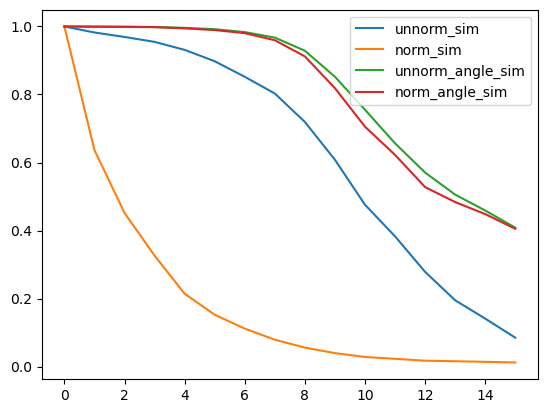

In [156]:
from matplotlib import pyplot as plt

plt.plot(unnorm_sims, label="unnorm_sim")
plt.plot(norm_sims, label="norm_sim")
plt.plot(unnorm_angle_sims, label="unnorm_angle_sim")
plt.plot(norm_angle_sims, label="norm_angle_sim")
plt.legend()
plt.show()

In [78]:
def compare_a(bundle_vec, targets):
    sim = 0
    for target in targets:
        sim += (similarity2(target, normalize(target+bundle_vec)))
    n = len(targets)
    sim /= n
    return sim

In [89]:
threshold = 0.80
max_order = []
for d in range(30+1):
    dims = int(2**(d/2))
    targets = [init_random_vec(dims) for _ in range(1000)]
    bundle_vec = init_random_vec(dims)*0
    for i in range(20):
        print(dims, d, i)
        noise = generate_noise(dims, 2**i)
        bundle_vec += noise
        sim = compare_a(bundle_vec, targets)
        if sim < threshold:
            break
    max_order.append(i-1)


1 0 0
1 1 0
2 2 0
2 2 1
2 3 0
2 3 1
4 4 0
4 4 1
4 4 2
5 5 0
5 5 1
5 5 2
5 5 3
8 6 0
8 6 1
8 6 2
11 7 0
11 7 1
11 7 2
16 8 0
16 8 1
16 8 2
22 9 0
22 9 1
22 9 2
22 9 3
32 10 0
32 10 1
32 10 2
32 10 3
45 11 0
45 11 1
45 11 2
45 11 3
45 11 4
64 12 0
64 12 1
64 12 2
64 12 3
64 12 4
64 12 5
90 13 0
90 13 1
90 13 2
90 13 3
90 13 4
90 13 5
128 14 0
128 14 1
128 14 2
128 14 3
128 14 4
128 14 5
128 14 6
181 15 0
181 15 1
181 15 2
181 15 3
181 15 4
181 15 5
181 15 6
256 16 0
256 16 1
256 16 2
256 16 3
256 16 4
256 16 5
256 16 6
256 16 7
362 17 0
362 17 1
362 17 2
362 17 3
362 17 4
362 17 5
362 17 6
362 17 7
512 18 0
512 18 1
512 18 2
512 18 3
512 18 4
512 18 5
512 18 6
512 18 7
512 18 8
724 19 0
724 19 1
724 19 2
724 19 3
724 19 4
724 19 5
724 19 6
724 19 7
724 19 8
1024 20 0
1024 20 1
1024 20 2
1024 20 3
1024 20 4
1024 20 5
1024 20 6
1024 20 7
1024 20 8
1448 21 0
1448 21 1
1448 21 2
1448 21 3
1448 21 4
1448 21 5
1448 21 6
1448 21 7
1448 21 8
1448 21 9
2048 22 0
2048 22 1
2048 22 2
2048 22 3
2048

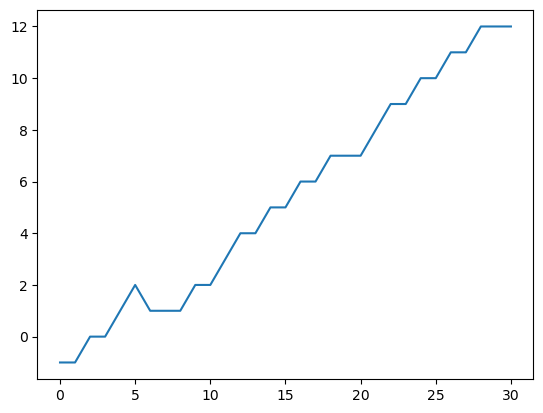

In [90]:
from matplotlib import pyplot as plt

plt.plot(max_order)
plt.show()